**Importing needed packages**

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

**Preparing datas**

In [143]:
dfIn = pd.read_csv('intakes.csv', delimiter = ',' )
dfOut = pd.read_csv('outcomes.csv', delimiter = ',') #reading dataframes

#Overview of structures and content
dfIn.head()
display(dfIn.info()) #Data types and non-null counts
display(dfIn.shape) #Number of rows and columns
display(dfIn.describe()) #Summary stats for numerical columns
display(dfIn.nunique())  #Count of unique values per column

dfOut.head()
display(dfOut.info())
display(dfOut.shape)
display(dfOut.describe())
display(dfOut.nunique())

#Replacing common placeholder values with NaN
dfIn.replace(['Unknown', 'unknown', 'None', 'NA', 'N/A', '', ' ', '?'], np.nan, inplace = True)
dfOut.replace(['Unknown', 'unknown', 'None', 'NA', 'N/A', '', ' ', '?'], np.nan, inplace = True)

#Getting rid of duplicates
dfIn.drop_duplicates(inplace = True)
dfOut.drop_duplicates(inplace = True)

#converting DateTime -> datetime64
#Dataset uses format MM/DD/YYYY HH:MM:SS AM/PM
dfIn['DateTime'] = pd.to_datetime(dfIn['DateTime'], format = '%m/%d/%Y %I:%M:%S %p', errors = 'coerce')
dfOut['DateTime'] = pd.to_datetime(dfOut['DateTime'], format = '%m/%d/%Y %I:%M:%S %p', errors = 'coerce')

#converting categorical flags -> category type
for col in dfIn.select_dtypes(include = 'object').columns:
    dfIn[col] = dfIn[col].astype('category')
for col in dfOut.select_dtypes(include = 'object').columns:
    dfOut[col] = dfOut[col].astype('category')

#Age upon intake and outcome -> number of days
def age_to_days(age_str):
    if pd.isna(age_str):
        return np.nan
    pattern = r'(\d+)\s*(year|month|week|day)s?'
    days = 0
    for number, unit in re.findall(pattern, age_str.lower()):
        number = int(number)
        if unit in ['year', 'years'] :
            days += number *365
        elif unit in ['month', 'months']:
            days += number * 30
        elif unit in ['week', 'weeks']:
            days += number * 7
        elif unit in ['day', 'days']:
            days += number
    return days

#applying conversion to DataSets
dfIn['Days upon Intake'] = dfIn['Age upon Intake'].apply(age_to_days)
dfOut['Days upon Outcome'] = dfOut['Age upon Outcome'].apply(age_to_days)

#Adding new flags, which we will need to answer the question
dfIn['Year'] = dfIn['DateTime'].dt.year
dfIn['Month'] = dfIn['DateTime'].dt.month
dfIn['Week'] = dfIn['DateTime'].dt.isocalendar().week.astype('Int64')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167556 entries, 0 to 167555
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         167556 non-null  object
 1   Name              119338 non-null  object
 2   DateTime          167556 non-null  object
 3   MonthYear         167556 non-null  object
 4   Found Location    167556 non-null  object
 5   Intake Type       167556 non-null  object
 6   Intake Condition  167556 non-null  object
 7   Animal Type       167556 non-null  object
 8   Sex upon Intake   167554 non-null  object
 9   Age upon Intake   167555 non-null  object
 10  Breed             167556 non-null  object
 11  Color             167556 non-null  object
dtypes: object(12)
memory usage: 15.3+ MB


None

(167556, 12)

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
count,167556,119338,167556,167556,167556,167556,167556,167556,167554,167555,167556,167556
unique,150561,29042,115549,133,67994,6,20,5,5,55,2966,650
top,A721033,Luna,09/23/2016 12:00:00 PM,June 2015,Austin (TX),Stray,Normal,Dog,Intact Male,1 year,Domestic Shorthair Mix,Black/White
freq,33,724,64,2189,30530,114927,142264,91648,56729,27379,33623,17386


Animal ID           150561
Name                 29042
DateTime            115549
MonthYear              133
Found Location       67994
Intake Type              6
Intake Condition        20
Animal Type              5
Sex upon Intake          5
Age upon Intake         55
Breed                 2966
Color                  650
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167559 entries, 0 to 167558
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         167559 non-null  object
 1   Name              119476 non-null  object
 2   DateTime          167559 non-null  object
 3   MonthYear         167559 non-null  object
 4   Date of Birth     167559 non-null  object
 5   Outcome Type      167515 non-null  object
 6   Outcome Subtype   76968 non-null   object
 7   Animal Type       167559 non-null  object
 8   Sex upon Outcome  167556 non-null  object
 9   Age upon Outcome  167512 non-null  object
 10  Breed             167559 non-null  object
 11  Color             167559 non-null  object
dtypes: object(12)
memory usage: 15.3+ MB


None

(167559, 12)

,Animal ID,Name,DateTime,MonthYear,Date of Birth,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
count,167559,119476,167559,167559,167559,167515,76968,167559,167556,167512,167559,167559
unique,150558,28979,139792,133,8486,11,26,5,5,55,2964,653
top,A721033,Luna,04/18/2016 12:00:00 AM,Jun 2019,05/01/2016,Adoption,Partner,Dog,Neutered Male,1 year,Domestic Shorthair Mix,Black/White
freq,33,724,39,2244,121,80724,39348,91604,58699,27844,33986,17407


Animal ID           150558
Name                 28979
DateTime            139792
MonthYear              133
Date of Birth         8486
Outcome Type            11
Outcome Subtype         26
Animal Type              5
Sex upon Outcome         5
Age upon Outcome        55
Breed                 2964
Color                  653
dtype: int64

**Descriptive Statistic**

*UNIVARIATE DESCRIPTIVE STATISTICS*: "Days upon Intake"

count    167523.000000
mean        710.064337
std        1021.477219
min           0.000000
25%          60.000000
50%         365.000000
75%         730.000000
max       10950.000000
Name: Days upon Intake, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

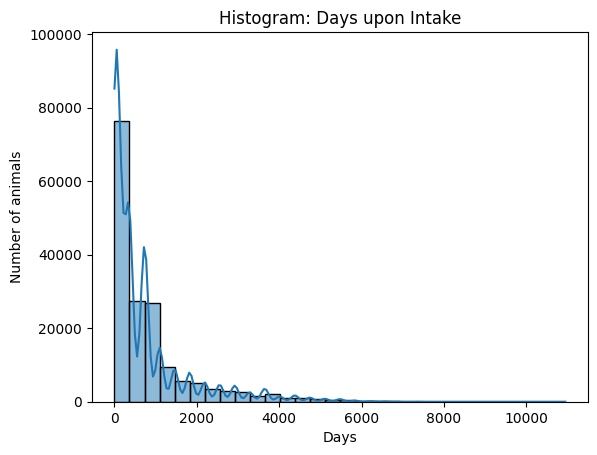

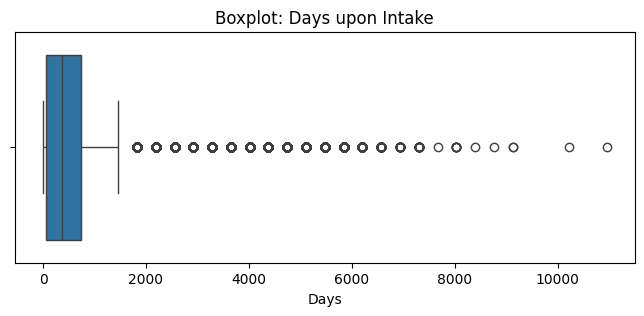

In [146]:
#Summary statistics for the numeric variable
print(dfIn['Days upon Intake'].describe())
#Histogram: vizualizes how animal ages(in days) are distributed at intake
sns.histplot(dfIn['Days upon Intake'], bins = 30, kde = True)
plt.title('Histogram: Days upon Intake')
plt.xlabel('Days')
plt.ylabel('Number of animals')
plt.show

#Boxplot: provides a compact view of the same data - showing median, quartiles and outliers
plt.figure(figsize=(8,3))
sns.boxplot(x = dfIn['Days upon Intake'])
plt.title('Boxplot: Days upon Intake')
plt.xlabel('Days')
plt.show

*UNIVARIATE DESCRIPTIVE STATISTICS*: "DateTime" (Year and Month)

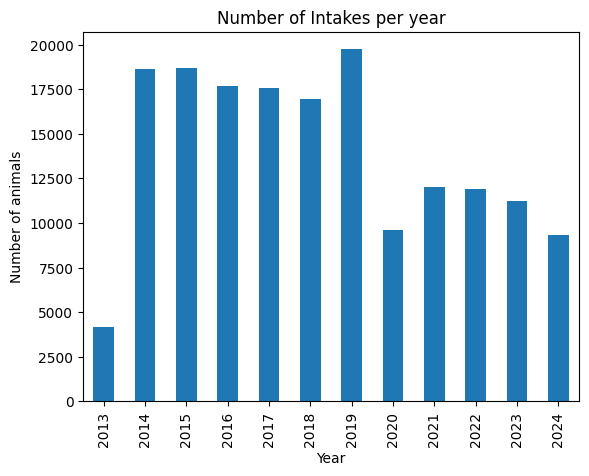

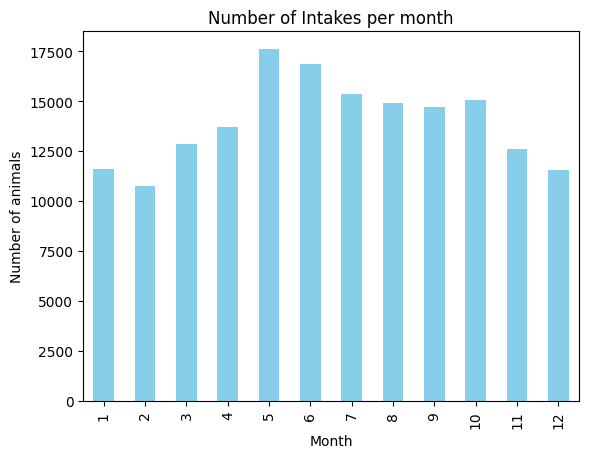

In [147]:
#Intakes per year
dfIn['Year'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Number of Intakes per year')
plt.xlabel('Year')
plt.ylabel('Number of animals')
plt.show()

#Intakes per month
dfIn['Month'].value_counts().sort_index().plot(kind = 'bar', color = 'skyblue')
plt.title('Number of Intakes per month')
plt.xlabel('Month')
plt.ylabel('Number of animals')
plt.show()

**Describing three other flags**

*UNIVARIATE DESCRIPTIVE STATISTICS*: "Animal Type"

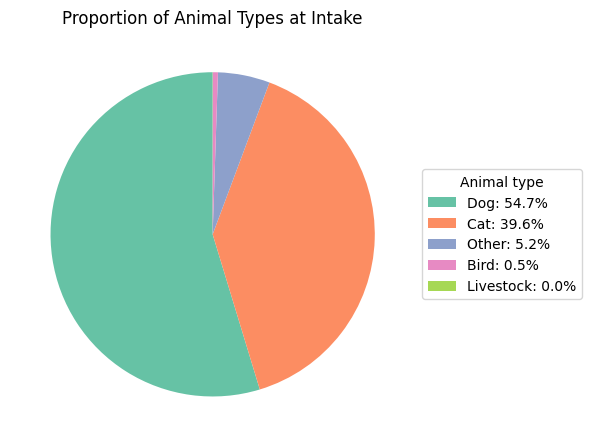

In [148]:
#Counting the number of occurences for each animal type
animal_counts = dfIn['Animal Type'].value_counts()

#Creating a pie chart
plt.figure(figsize=(6,6))
wedges, texts = plt.pie(
    animal_counts,
    autopct = None,
    startangle = 90,
    colors = sns.color_palette('Set2')
)
plt.title('Proportion of Animal Types at Intake')

#Calculating percentages and preparing labels for legends
percentages = (animal_counts / animal_counts.sum()*100).round(1)
labels = [f'{animal}: {pct}%' for animal, pct in zip(animal_counts.index, percentages)]

#Adding legend with percentages instead of labels on the cart
#so it would look more accurate and readable
plt.legend(
    wedges,
    labels,
    title = "Animal type",
    loc = "center left",
    bbox_to_anchor = (1, 0, 0.5, 1)    
)
plt.tight_layout()
plt.show()

*UNIVARIATE DESCRIPTIVE STATISTICS*: "Intake Type"

<function matplotlib.pyplot.show(close=None, block=None)>

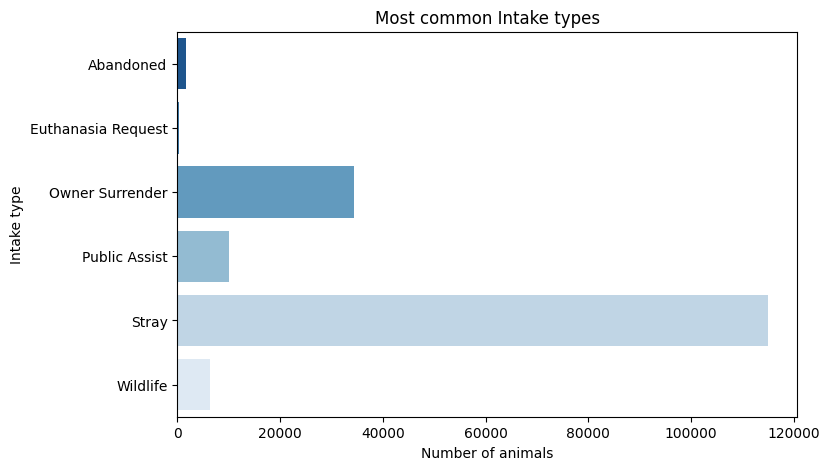

In [150]:
plt.figure(figsize=(8,5))
sns.barplot(
    y = dfIn['Intake Type'].value_counts().index, #categorising on the y-axes
    x = dfIn['Intake Type'].value_counts().values, #Counting on the x-axis
    palette = 'Blues_r', 
    hue =  dfIn['Intake Type'].value_counts().index, 
    legend = False
)
plt.title('Most common Intake types')
plt.xlabel('Number of animals')
plt.ylabel('Intake type')
plt.show

*UNIVARIATE DESCRIPTIVE STATISTICS*: "Sex upon Intake"

<function matplotlib.pyplot.show(close=None, block=None)>

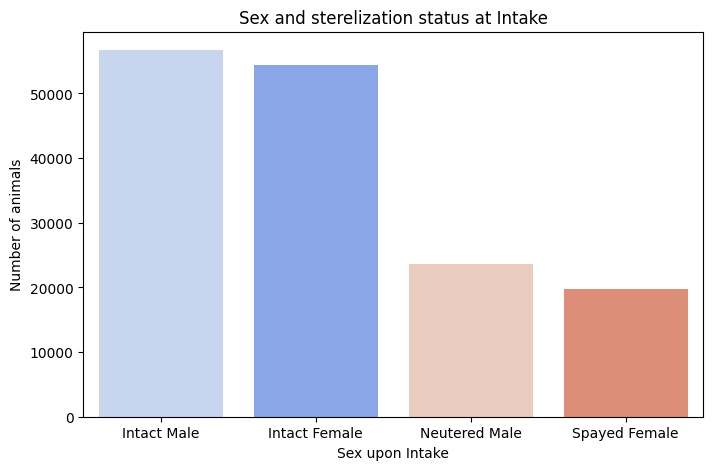

In [89]:
plt.figure(figsize = (8,5))
sns.countplot(x = 'Sex upon Intake',
             data = dfIn,
             palette = 'coolwarm',
             order = dfIn['Sex upon Intake'].value_counts().index,
             hue = 'Sex upon Intake',
             legend = False)
plt.title('Sex and sterelization status at Intake')
plt.xlabel('Sex upon Intake')
plt.ylabel('Number of animals')
plt.show

*BIVARIATE DESCRIPTIVE STATISTICS*: Relation between "Intake Type" and "Sex upon Intake"

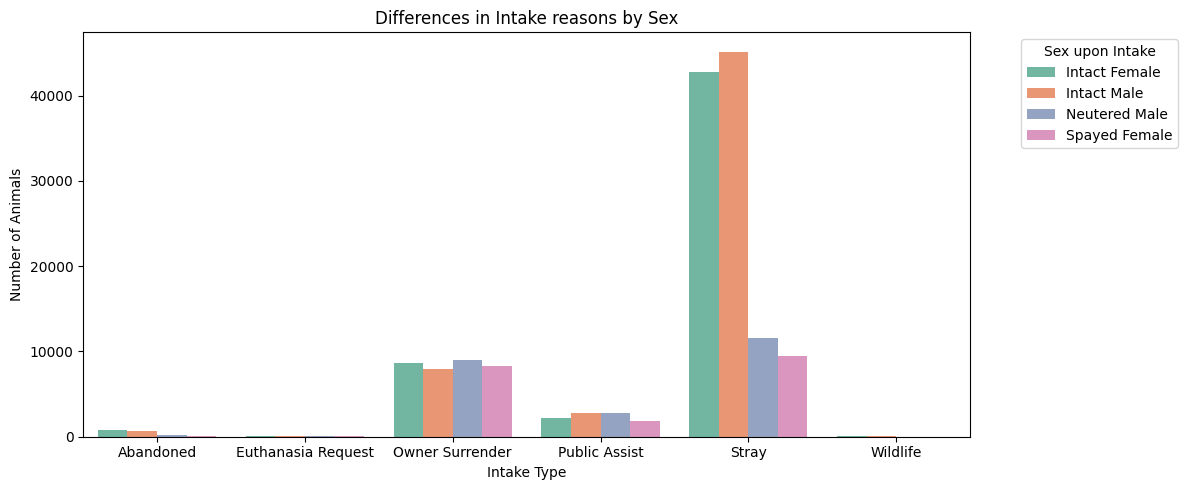

In [152]:
plt.figure(figsize = (12,5))
sns.countplot(
    data = dfIn,
    x = 'Intake Type', #Intake reason on the x-axis
    hue = 'Sex upon Intake', #color by sex/sterilization category
    palette = 'Set2'
)
plt.title('Differences in Intake reasons by Sex')
plt.xlabel('Intake Type')
plt.ylabel('Number of Animals')
plt.legend(
    title = 'Sex upon Intake',
    bbox_to_anchor = (1.05, 1), 
    loc = 'upper left'
)
plt.tight_layout()
plt.show()

*BIVARIATE DESCRIPTIVE STATISTICS*: Relation between "Animal Type" and "Days in Shelter"

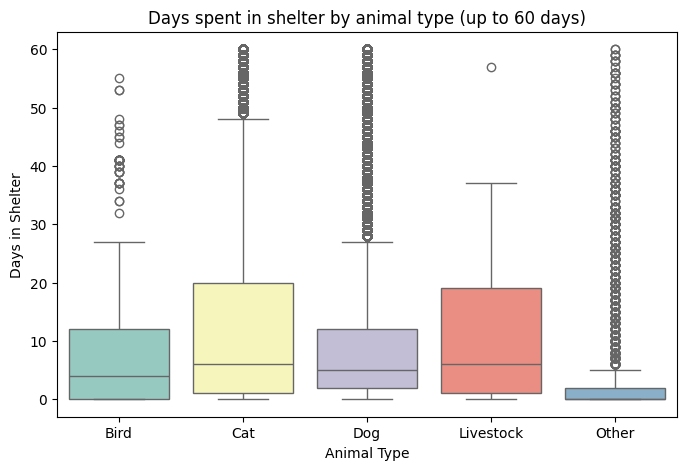

In [153]:
#merging intake and outcome datasets on Animal ID and Animal Type 
#This allows us to calculate how many days each animal stayed in the shelter
merge1 = pd.merge(
    dfIn[['Animal ID', 'DateTime', 'Animal Type']],
    dfOut[['Animal ID', 'DateTime', 'Animal Type']],
    on = ['Animal ID', 'Animal Type'],
    how = 'inner',
    suffixes = ('_in', '_out')
)

#Calculating the difference between intake and outcome dates
merge1['Days in shelter'] = (merge1['DateTime_out'] - merge1['DateTime_in']).dt.days
#Filter out data that doesnt make sence
merge1 = merge1[merge1['Days in shelter'].notna() & (merge1['Days in shelter'] >= 0)]

#limit to 60 days for better readability
plt.figure(figsize = (8,5))
filtered = merge1[merge1['Days in shelter'] <= 60]
sns.boxplot(
    data = filtered,
    x = 'Animal Type',
    y = 'Days in shelter',
    palette = 'Set3',
    hue = 'Animal Type',
    legend = False
)
plt.title('Days spent in shelter by animal type (up to 60 days)')
plt.xlabel('Animal Type')
plt.ylabel('Days in Shelter')
plt.show()

**GIVEN QUESTIONS**

1. Does Outcome Type depend on Intake Type?

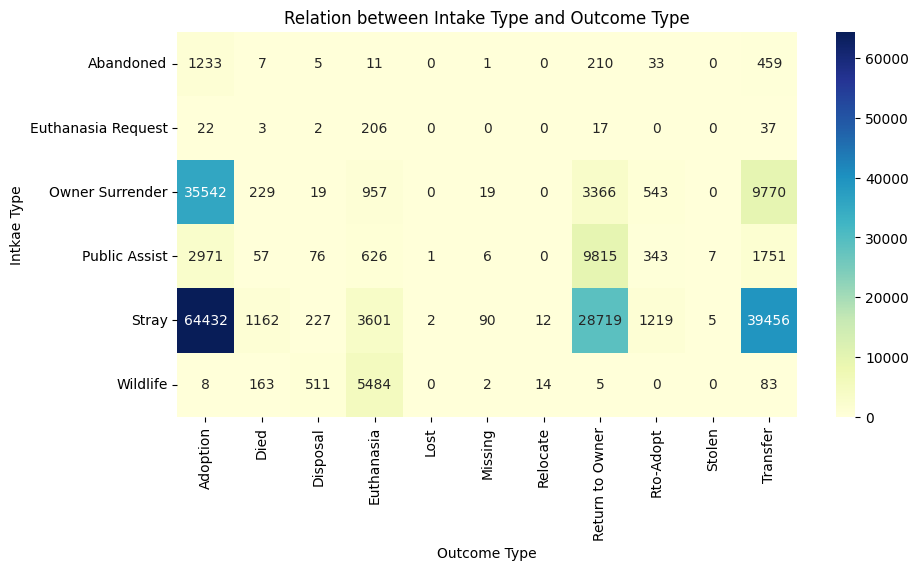

In [154]:
#Merging datasets on AnimalID tp connect intake and outcome records
merge_q1 = pd.merge(
    dfIn[['Animal ID', 'Intake Type']],
    dfOut[['Animal ID', 'Outcome Type']],
    on = 'Animal ID',
    how = 'inner'
)
#Ctosstab because we need to know how many each combination of categories occurs
cross_tab = pd.crosstab(merge_q1['Intake Type'], merge_q1['Outcome Type'])
plt.figure(figsize = (10,5))
sns.heatmap(cross_tab,
           cmap = 'YlGnBu',
           annot = True,
           fmt = 'd')

plt.title('Relation between Intake Type and Outcome Type')
plt.xlabel('Outcome Type')
plt.ylabel('Intkae Type')
plt.show()

According to heatmap we can see:
- How an animal arrives can predict what will happen
- **Strays** are usually either returned or adopted
- **Owner surrenders** are rehomed
- **Wildlife** cases mostly end in euthanasia

2. Does age play a role in adoption?

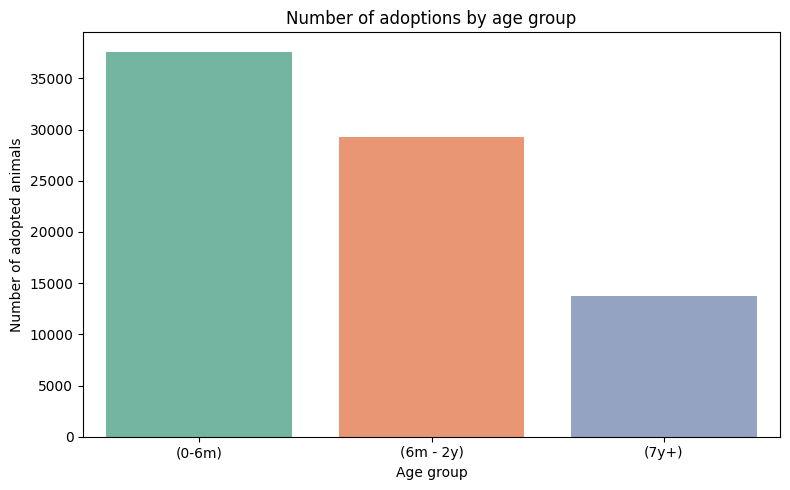

In [155]:
#Defining age bins in days and corresponding labels
bins = [0, 180, 730, np.inf]
labels = ['(0-6m)', '(6m - 2y)', '(7y+)']
#Creating a new categorical variable representing age group
dfOut['AgeGroup'] = pd.cut(dfOut['Days upon Outcome'], bins = bins, labels = labels)
#Counting how many adoptions occured in each age group
adopt_counts = (
    dfOut[dfOut['Outcome Type'] == 'Adoption']
    .groupby('AgeGroup', observed = True)
    .size()
    .reset_index(name = 'Count')
)
plt.figure(figsize = (8,5))
sns.barplot(
    data = adopt_counts,
    x = 'AgeGroup',
    y = 'Count',
    palette = 'Set2',
    hue = 'AgeGroup',
    legend = False
)
plt.title('Number of adoptions by age group')
plt.xlabel('Age group')
plt.ylabel('Number of adopted animals')
plt.tight_layout()
plt.show()

The chart shows that **age plays a role in adoption decision**:
younger animals are adopted **more frequently** than older ones

3. Is the number of animal intakes constant throughout the year, or are there periods with higher/lower activity?

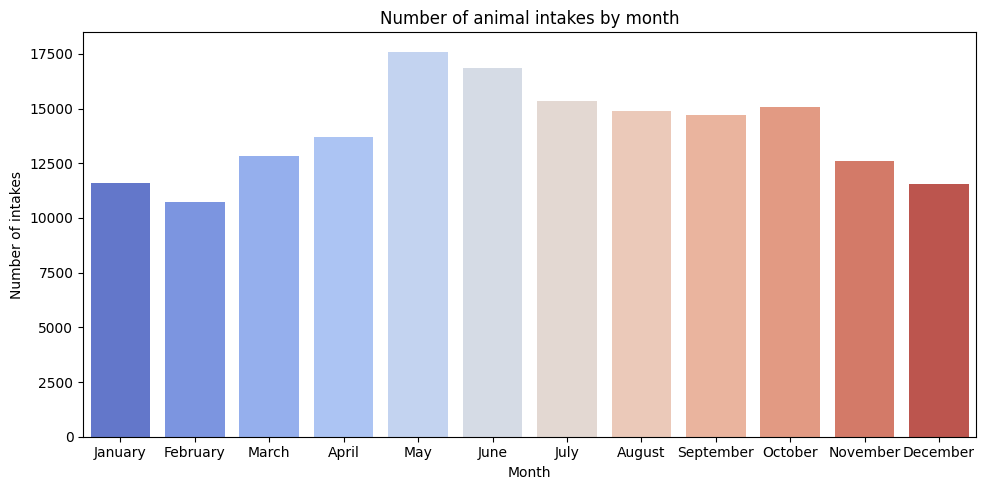

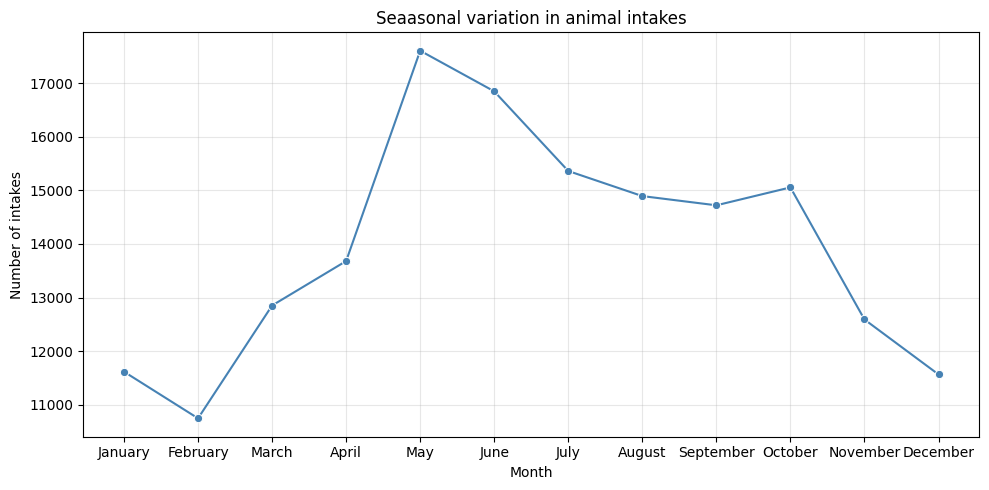

In [156]:
#Extracting month and month name from the intake datetime column
dfIn['Month'] = dfIn['DateTime'].dt.month
dfIn['MonthName'] = dfIn['DateTime'].dt.month_name()

#Counting number of intakes for each month, keeping correct chronological order
month_counts = (
    dfIn['MonthName']
    .value_counts()
    .reindex([
        'January', 'February', 'March', 'April', 'May', 'June', 'July',
        'August', 'September', 'October', 'November', 'December'
    ])
)

plt.figure(figsize = (10,5))
sns.barplot(
    x = month_counts.index,
    y = month_counts.values,
    palette = 'coolwarm',
    hue = month_counts.index,
    legend = False
)

plt.title('Number of animal intakes by month')
plt.xlabel('Month')
plt.ylabel('Number of intakes')
plt.tight_layout()
plt.show()

plt.figure(figsize = (10,5))
sns.lineplot(
    x = month_counts.index,
    y = month_counts.values,
    marker = 'o',
    color = 'steelblue'
)
plt.title('Seaasonal variation in animal intakes')
plt.xlabel('Month')
plt.ylabel('Number of intakes')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

As a result we can see that **animal intake is not constant throughout the year** 
There is **seasonal pattern**: more animals are arriving during warner months, during **winter months**, intake levels decrease

**Additional questions**

1. Does the probability of adoption differ between dogs and cats?

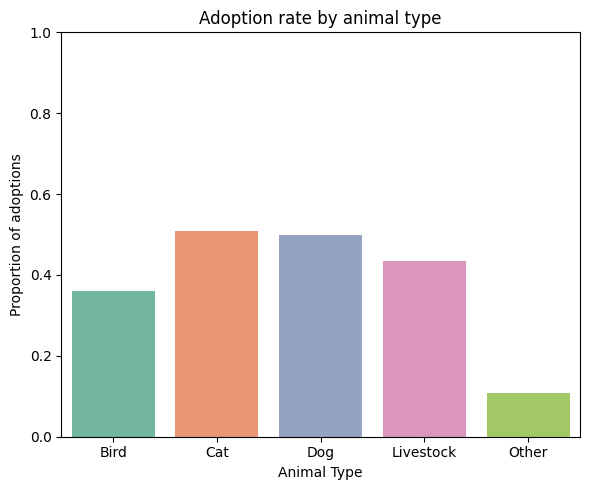

In [119]:
#Calculating proportion of each outcome type for each animal type
adopt_prob = (
    dfOut.groupby('Animal Type', observed = True)['Outcome Type']
    .value_counts(normalize = True)
    .rename('Proportion')
    .reset_index()
)
#Filtering only adoption case
adopt_prob_adoption = adopt_prob[adopt_prob['Outcome Type']  == 'Adoption']

plt.figure(figsize = (6,5))
sns.barplot(
    data = adopt_prob_adoption,
    x = 'Animal Type',
    y = 'Proportion',
    palette = 'Set2',
    hue = 'Animal Type',
    legend = False
)
plt.title('Adoption rate by animal type')
plt.xlabel('Animal Type')
plt.ylabel('Proportion of adoptions')
plt.ylim(0,1)
plt.tight_layout()
plt.show()

**dogs and cats have almost equel chansec of adoption** with only a slight preference for cats

2. Is there a difference between males and females in the outcome types?

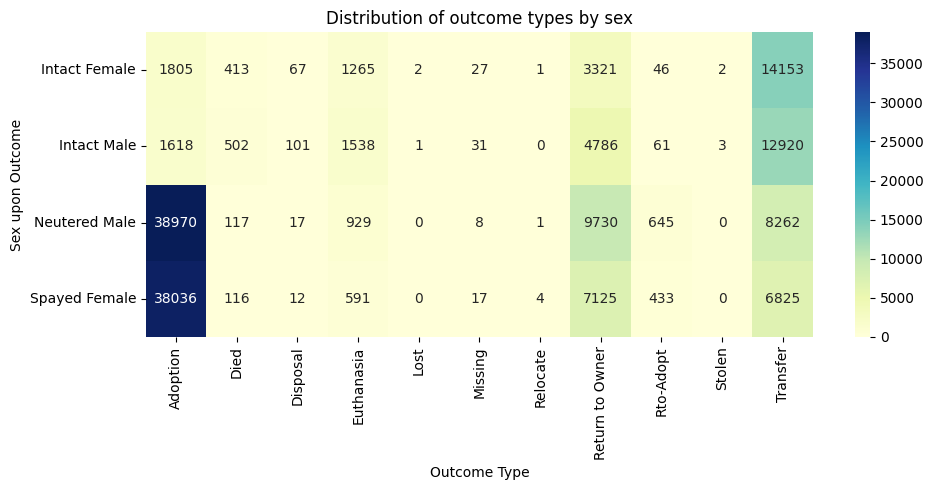

In [122]:
sex_outcome = pd.crosstab(dfOut['Sex upon Outcome'], dfOut['Outcome Type'])

plt.figure(figsize = (10,5))
sns.heatmap(
    sex_outcome,
    annot = True,
    fmt = 'd',
    cmap = 'YlGnBu'
)
plt.title('Distribution of outcome types by sex')
plt.xlabel('Outcome Type')
plt.ylabel('Sex upon Outcome')
plt.tight_layout()
plt.show()

the heatmap suggests that **sterelization has a strong posotove impact** on adoption outcomes:
neutered and spayed animals are **adopted much more often** than intact ones

3. How has the number of adoptions changed over the years?

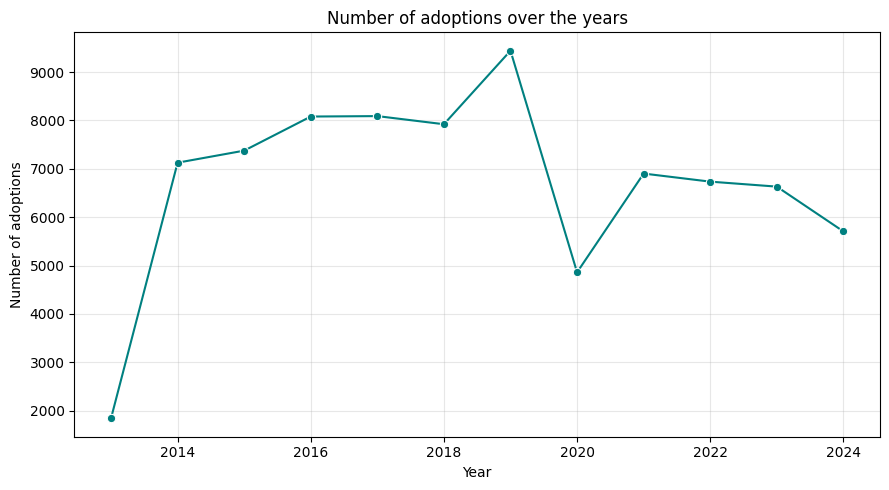

In [157]:
#Extracting the year from the outcome DateTime column
dfOut['Year'] = dfOut['DateTime'].dt.year
#Counting number of adoptions for each year
adopt_by_year = (
    dfOut[dfOut['Outcome Type'] == 'Adoption']
    .groupby('Year')
    .size()
    .reset_index(name = 'Count')
)

plt.figure(figsize = (9,5))
sns.lineplot(
    data = adopt_by_year,
    x = 'Year',
    y = 'Count',
    marker = 'o',
    color = 'teal',
)
plt.title('Number of adoptions over the years')
plt.xlabel('Year')
plt.ylabel('Number of adoptions')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

- The number of adoptions **increased steadily** from 2013 until around **2019**, when it reached its **peak (over 9,000 adoptions)**.  
- In **2020**, there was a **sharp decline** in adoptions — this drop likely coincides 
  with the **COVID-19 pandemic**, which affected shelter operations and public visits.  
- After 2020, adoption numbers **recovered partially**, stabilizing between **6,000–7,000 adoptions per year**, but **never returned to pre-pandemic levels**

4. Which locations outside the shelter have the highest number of animals?

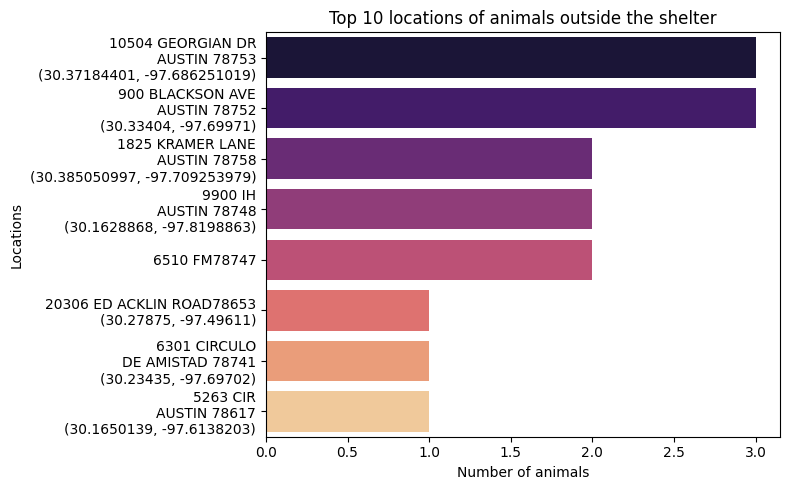

In [158]:
#Reading the locations dataset
dfLoc = pd.read_csv('locations.csv', delimiter = ',')
#filtering animals outside the shelter
outside_locs = dfLoc[dfLoc['At AAC'] == 'No (contact for more info)']
#counting the number of animals found at each location and select top 10
top_locs = (
    outside_locs['Found Location']
    .value_counts()
    .head(10)
    .reset_index()
)
top_locs.columns = ['Location', 'Count']

plt.figure(figsize = (8,5))
sns.barplot(
    data = top_locs,
    y = 'Location',
    x = 'Count',
    palette = 'magma',
    hue = 'Location',
    legend = False
)
plt.title('Top 10 locations of animals outside the shelter')
plt.xlabel('Number of animals')
plt.ylabel('Locations')
plt.tight_layout()
plt.show()

The visualization presents the **top 10 external locations** with the highest number of animal reports.
- The most frequent locations include **10504 Georgian Dr** and **900 Blackson Ave** in Austin.
- Other areas such as **1825 Kramer Lane** and **9900 IH** also show high animal presence.